## ***Imports***
---

In [19]:
import pandas as pd
import numpy as np

import json

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## ***Read Data***
---

In [29]:
# read json

data = json.loads(open('data/wmt-human_en_de.json').read())
data

{'dataset': 'WMT-Human-Evaluation (Freitag et al., Transactions of the Association for Computational Linguistics 2021)',
 'dataset_url': 'https://github.com/google/wmt-mqm-human-evaluation',
 'expert_annotator': 'true',
 'original_prompt': False,
 'annotations': [{'metric': 'quality',
   'category': 'graded',
   'prompt': 'Your task is to evaluate the quality of machine translation output at the segment level, where a segment may consist of one or more sentences. You will assess the overall quality of each translation segment and assign a rating on a scale from 0 to 6.\n\nRating Scale:\n\n0: Nonsense/No meaning preserved: Nearly all information is lost between the translation and source. Grammar is irrelevant.\n2: Some Meaning Preserved: The translation preserves some of the meaning of the source but misses significant parts. The narrative is hard to follow due to fundamental errors. Grammar may be poor.\n4: Most Meaning Preserved and Few Grammar Mistakes: The translation retains most 

## ***Prompt***
---

- Show prompt:

In [30]:
prompt = data["annotations"][0]["prompt"]
prompt

'Your task is to evaluate the quality of machine translation output at the segment level, where a segment may consist of one or more sentences. You will assess the overall quality of each translation segment and assign a rating on a scale from 0 to 6.\n\nRating Scale:\n\n0: Nonsense/No meaning preserved: Nearly all information is lost between the translation and source. Grammar is irrelevant.\n2: Some Meaning Preserved: The translation preserves some of the meaning of the source but misses significant parts. The narrative is hard to follow due to fundamental errors. Grammar may be poor.\n4: Most Meaning Preserved and Few Grammar Mistakes: The translation retains most of the meaning of the source. It may have some grammar mistakes or minor contextual inconsistencies.\n6: Perfect Meaning and Grammar: The meaning of the translation is completely consistent with the source and the surrounding context (if applicable). The grammar is also correct.\nIntermediate levels 1, 3 and 5 can also be 

- Write to file:

In [31]:
with open("prompt.txt", "w", encoding="utf-8") as f:
    f.write(prompt)

## ***EDA***
---

- JSON to Pandas df:

In [32]:
instances = data["instances"]


# Flatten the nested structure for easier analysis
flattened_data = []
for instance in instances:
    row = {
        "id": instance["id"],
        "source": instance["instance"]["source"],
        "reference": instance["instance"]["reference"],
        "translation": instance["instance"]["translation"],
        "mean_human_score": instance["annotations"]["quality"]["mean_human"],
        "individual_human_scores": instance["annotations"]["quality"]["individual_human_scores"]
    }
    flattened_data.append(row)


df = pd.DataFrame(flattened_data)
df['n_annotations'] = df['individual_human_scores'].apply(len)

print(df.shape)
df.head()

(9871, 7)


,id,source,reference,translation,mean_human_score,individual_human_scores,n_annotations
0,0,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",3.333333,"[4, 2, 4]",3
1,1,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",4.333333,"[4, 5, 4]",3
2,2,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",4.666667,"[5, 5, 4]",3
3,3,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",4.000000,"[4, 4, 4]",3
4,4,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",2.666667,"[4, 0, 4]",3


- N annotators per observation:

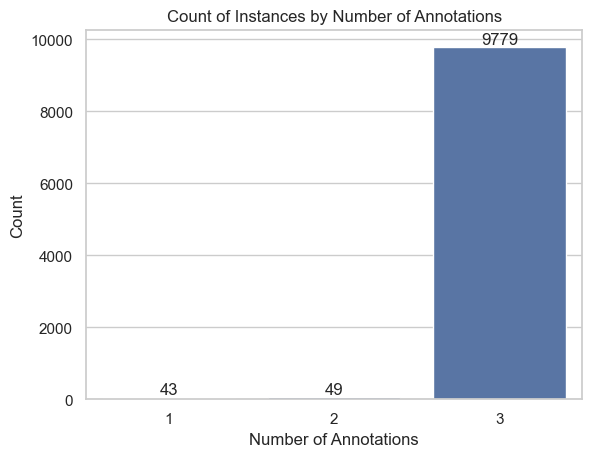

In [33]:
# Create the countplot
ax = sns.countplot(data=df, x='n_annotations')

# Annotate the bars
for p in ax.patches:
    height = p.get_height()  # Get the height of the bar
    ax.text(
        p.get_x() + p.get_width() / 2.,  # X position of the annotation (center of the bar)
        height + 0.1,  # Y position of the annotation (slightly above the bar)
        f'{int(height)}',  # Text to display (height of the bar)
        ha='center',  # Horizontal alignment
        va='bottom'  # Vertical alignment
    )

# Add labels and title
plt.xlabel('Number of Annotations')
plt.ylabel('Count')
plt.title('Count of Instances by Number of Annotations');

- Drop observations with less than 3 annotations:

In [34]:
n_rows_before = df.shape[0]
df = df[df['n_annotations'] == 3]
n_rows_after = df.shape[0]

print(f"Number of rows before filtering: {n_rows_before}")
print(f"Number of rows after filtering: {n_rows_after}")
print(f"Number of rows removed: {n_rows_before - n_rows_after}")

Number of rows before filtering: 9871
Number of rows after filtering: 9779
Number of rows removed: 92


In [35]:
# Create new olumns for the individual human scores 

for i in range(3):
    df[f'human_#{i}'] = df['individual_human_scores'].apply(lambda x: x[i])

df.head(3)

,id,source,reference,translation,mean_human_score,individual_human_scores,n_annotations,human_#0,human_#1,human_#2
0,0,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",3.333333,"[4, 2, 4]",3,4,2,4
1,1,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",4.333333,"[4, 5, 4]",3,4,5,4
2,2,Michael Jackson wore tape on his nose to get f...,Ehemaliger Bodyguard berichtet: Michael Jackso...,"Michael Jackson trug Klebeband auf der Nase, u...",4.666667,"[5, 5, 4]",3,5,5,4
